Critical Chi-Square Value: 3.841458820694124
Profile Likelihoods V2
[1.37732859e-02 1.50722740e-01 2.29232589e-02 2.26044458e+02
 1.63889641e+03 1.14544830e+03 1.29684287e-02 1.07330158e-09
 1.36158066e+02 1.26818480e+01 5.99751737e-01 2.16607627e+03
 4.43904210e+02 3.87837458e-02 4.24409887e+04]
[1.60000037e-02 1.58899992e-01 2.66000074e-02 8.00000004e+01
 1.43999990e+03 9.50000055e+02 2.92999997e-02 1.54600000e-09
 1.12000019e+02 2.99999934e+02 5.00000005e-01 1.54950001e+03
 4.99999979e+02 3.19999951e-02 3.55139999e+04]


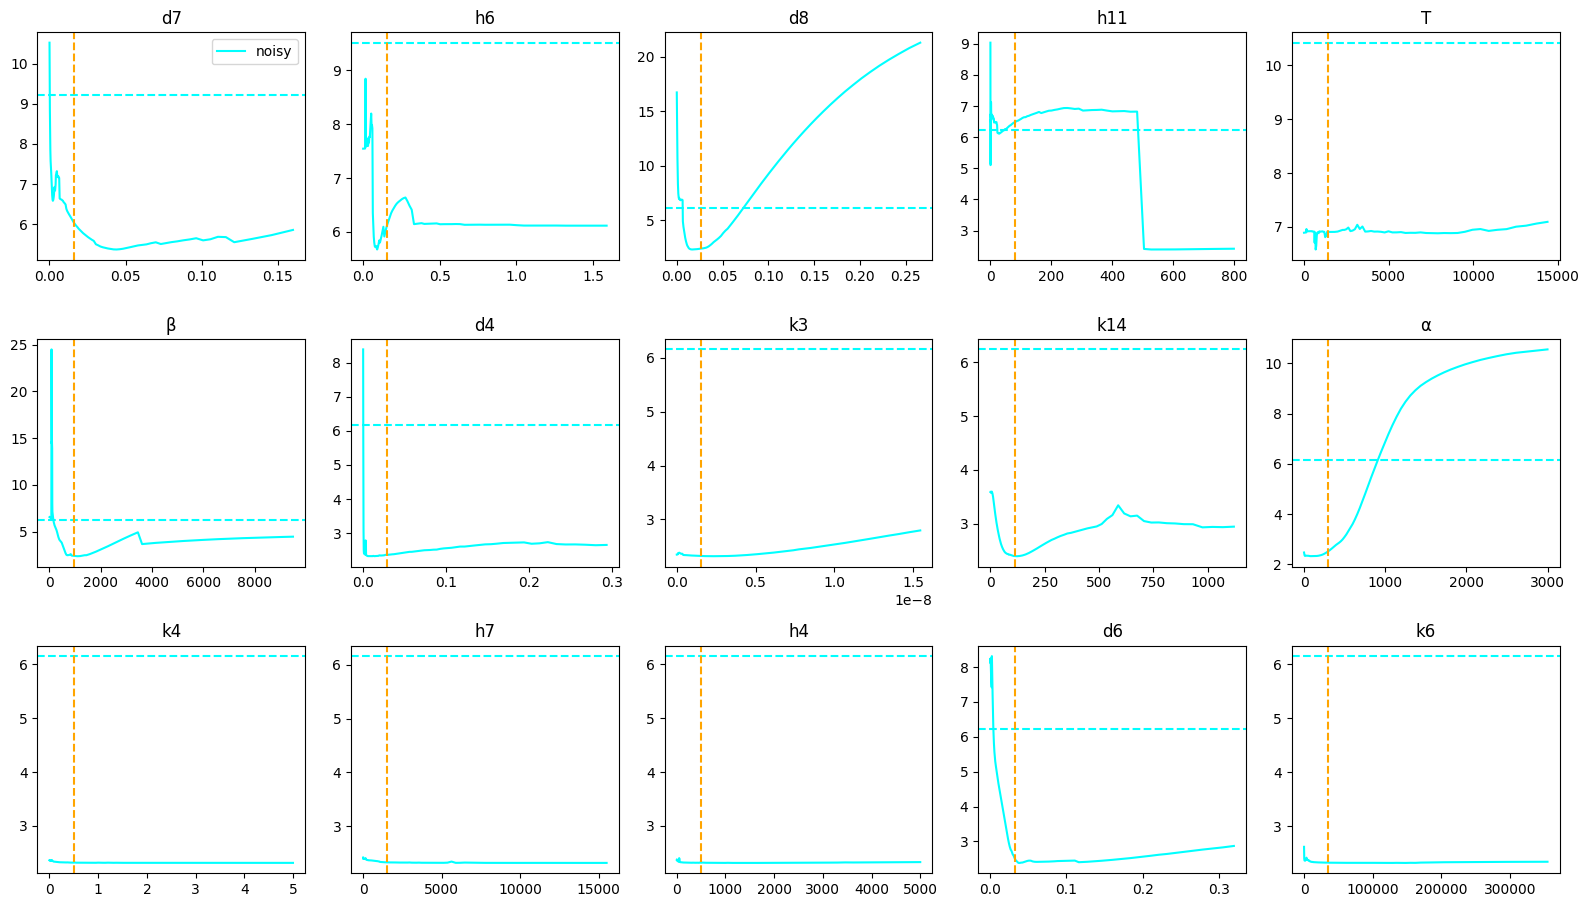

In [8]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from ITIS_Model_funcs import ITIS, ITIS_modelcall, get_nominal_param
from scipy.integrate import odeint

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'\u03B1', 'k', '\u03B2', 'L', '\u03B5', '\u03B4', 'T', 'Nc']



D = '1'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13
N = 'nonoise'   #'noisy' or 'nonoise'. Not perfect, some paths may need to be tweaked.


if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]


with open('PL_results_V2\\PL_' + D + dpoints + 'noisy.pkl', 'rb') as f:
    results1 = pickle.load(f)

# all_results = {
#     'param_ids' : param_ids,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'true_sol' : true_sol,
#     'J_save': J_save,
#     'par_save': par_save,
#     'param_global_all': param_global_all
# }
#
param_ids1 = results1['param_ids']
t_data1 = results1['t_data']
y_data1 = results1['y_data']
true_sol1 = results1['true_sol']
J_save1 = results1['J_save'].copy()
par_save1 = results1['par_save'].copy()
param_global_all1 = results1['param_global_all']

# with open('PL_results_V2\\PL_' + D + dpoints + 'nonoise.pkl', 'rb') as f:
#     results2 = pickle.load(f)
#
# param_ids2 = results2['param_ids']
# t_data2 = results2['t_data']
# y_data2 = results2['y_data']
# true_sol2 = results2['true_sol']
# J_save2 = results2['J_save'].copy()
# par_save2 = results2['par_save'].copy()
# param_global_all2 = results2['param_global_all']

from scipy.stats import chi2
#
alpha = 0.05  # Significance level
df = 1        # Degrees of freedom

# Calculate the critical value
critical_value = chi2.ppf(1 - alpha, df)

print(f"Critical Chi-Square Value: {critical_value}")

# for i in range(len(param_ids)):
#
#     plt.figure()
#     plt.title(paramtitles[param_ids[i]])
#     plt.plot(par_save[i,i,:],J_save[i,:])
#     plt.axhline(y=critical_value, color='r')
#     plt.show()

if param_ids1 != param_ids2:
    print("PARAM ORDER DOES NOT MATCH")

fig, axs = plt.subplots(4,5, figsize = (16,12))
CI = np.zeros((20,2))
for i in range(4):

    for k in range(5):
        if i*5 + k>= len(param_ids1):
            for r in range(k,5):
                axs[i,r].remove()
            break

        axs[i, k].plot(np.exp(par_save1[i*5 + k, i*5 +k,:]),J_save1[i*5 + k,:], label = "noisy", color = 'cyan')
        #axs[i, k].plot(np.exp(par_save2[i*5 + k, i*5 +k,:]),J_save2[i*5 + k,:], label = "noiseless", color = 'orange')
        axs[i, k].axhline(y=critical_value+np.min(J_save1[i*5 + k,:]), color='cyan', linestyle='--')
        #axs[i, k].axhline(y=critical_value+np.min(J_save2[i*5 + k,:]), color='orange', linestyle='--')
        axs[i,k].set_title(param_titles[param_ids1[i*5 + k]])
        #axs[i,k].axvline(x = np.exp(param_global_all1[i*5 + k]), color = 'cyan', linestyle='--')
        axs[i,k].axvline(x = np.exp(param_global_all2[i*5 + k]), color = 'orange', linestyle = '--')
# for ax in axs.flat:
#     ax.set_xticks([])
axs[0,0].legend()
fig.tight_layout()
#fig.savefig('FIGS\\PL_results_' + N + D + dpoints + '.png')
print("Profile Likelihoods V2")
print(np.exp(param_global_all1))
print(np.exp(param_global_all2))

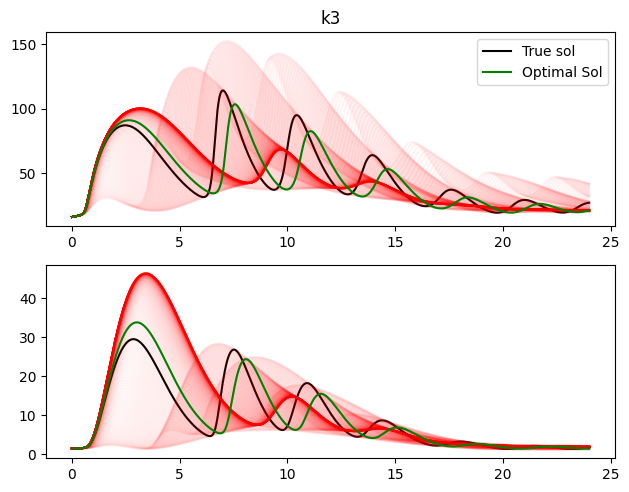

In [13]:
param_log, IC = get_nominal_param()
dt = .05
t_data = np.arange(0,24+dt,dt)
par = 7
true_sol = ITIS_modelcall(param_log[0],t_data,0,output_ids,param_log,IC)

for j in range(1): ##Can be expanded to run all identifiable param
    fig, axs = plt.subplots(len(output_ids))

    for k in range(len(output_ids)): #Loop through each model state for given design
        axs[k].plot(t_data, true_sol[:,k], color = 'black', label = 'True sol')

        for i in range(200): #Plot all 200 parameter value solutions
            param_in = par_save1[par,par,i]
            par_id = param_ids1[par]
            sol = ITIS_modelcall(param_in,t_data, par_id,output_ids,param_log,IC)
            axs[k].plot(t_data,sol[:,k], color = 'red', alpha = .05)

        opt_sol = ITIS_modelcall(param_global_all1[par],t_data, param_ids1[par],output_ids,param_log,IC)
        axs[k].plot(t_data,opt_sol[:,k], color = 'green', label = 'Optimal Sol')

    fig.tight_layout()
    axs[0].set_title(param_titles[param_ids1[par]])
    axs[0].legend()
    #CURRENTLY USES NOMINAL PARAM. CHANGE TO OPTIMIZED VALUES?